<a href="https://colab.research.google.com/github/eyedecay/RLImplementations/blob/main/src/brax_mujoco_implementations/PPO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install mujoco
!pip install mujoco_mjx
!pip install brax
!pip install playground

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.7/232.7 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.8/19.8 MB 98.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 94.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 745.5/745.5 kB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 356.9/356.9 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.4/172.4 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 107.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.1/163.1 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 110.4 MB/s eta 0:00:00


In [5]:
import os
os.environ["MUJOCO_GL"] = "egl"

In [6]:
from datetime import datetime
import functools
import os
from typing import Any, Dict, Sequence, Tuple, Union
from brax import base
from brax import envs
from brax import math
from brax.base import Base, Motion, Transform
from brax.base import State as PipelineState
from brax.envs.base import Env, PipelineEnv, State
from brax.io import html, mjcf, model
from brax.mjx.base import State as MjxState
from brax.training.agents.ppo import networks as ppo_networks
from brax.training.agents.ppo import train as ppo
from brax.training.agents.sac import networks as sac_networks
from brax.training.agents.sac import train as sac
from etils import epath
from flax import struct
from flax.training import orbax_utils
from IPython.display import HTML, clear_output
import jax
from jax import numpy as jp
from matplotlib import pyplot as plt
import mediapy as media
from ml_collections import config_dict
import mujoco
from mujoco import mjx
import numpy as np
from orbax import checkpoint as ocp

In [7]:
from mujoco_playground import registry
env = registry.load("CartpoleBalance")
config = registry.get_default_config("CartpoleBalance")

Warp 1.16.0 initialized:
   CUDA Toolkit 12.9, Driver 13.0
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "Tesla T4" (15 GiB, sm_75, mempool enabled)
   Kernel cache:
     /root/.cache/warp/1.16.0


In [9]:
print(type(env))
print("impl:", env.mjx_model.impl)
print("mj_model:", type(env.mj_model))
print("mjx_model:", type(env.mjx_model))

print(jax.devices())
print(jax.default_backend())

<class 'mujoco_playground._src.dm_control_suite.cartpole.Balance'>
impl: Impl.WARP
mj_model: <class 'mujoco._structs.MjModel'>
mjx_model: <class 'mujoco.mjx._src.types.Model'>
[CudaDevice(id=0)]
gpu


Rollout


In [5]:
jit_reset = jax.jit(env.reset)
jit_step = jax.jit(env.step)

state = jit_reset(jax.random.PRNGKey(0))
rollout = [state]

action_frequency = 0.5

for step_index in range(config.episode_length):
  actions = []
  for action_index in range(env.action_size):

    actions.append(
            jp.sin(
                state.data.time * 2 * jp.pi * action_frequency
                + action_index * 2 * jp.pi / env.action_size
            )
        )

  actions = jp.array(actions)

  state = jit_step(state, actions)

  rollout.append(state)

frames = env.render(rollout)

media.show_video(frames, fps=1.0 / env.dt)




Module mujoco.mjx.warp.ffi 7a22eb4 load on device 'cuda:0' took 3.00 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.smooth 2b7c7bf load on device 'cuda:0' took 7.01 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.constraint 5b5fe2d load on device 'cuda:0' took 0.50 ms  (cached)
Module _friction_dof__locals__kernel_79a5d781 79a5d78 load on device 'cuda:0' took 0.66 ms  (cached)
Module _limit_slide_hinge__locals__kernel_2e9cb608 2e9cb60 load on device 'cuda:0' took 0.76 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.forward 7b12154 load on device 'cuda:0' took 1.57 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.passive d8c18c6 load on device 'cuda:0' took 1.80 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.forward 8f02867 load on device 'cuda:0' took 1.45 ms  (cached)
Module _qfrc_smooth__locals__kernel_b98573a2 b98573a load on device 'cuda:0' took 0.51 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.support 5a42

100%|██████████| 1001/1001 [00:55<00:00, 18.03it/s]


This browser does not support the video tag.


Brax

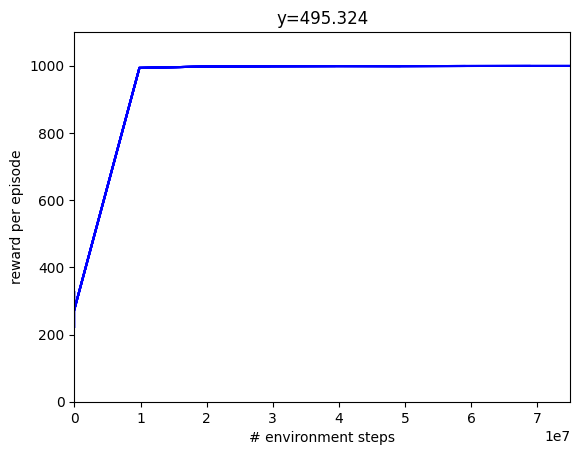

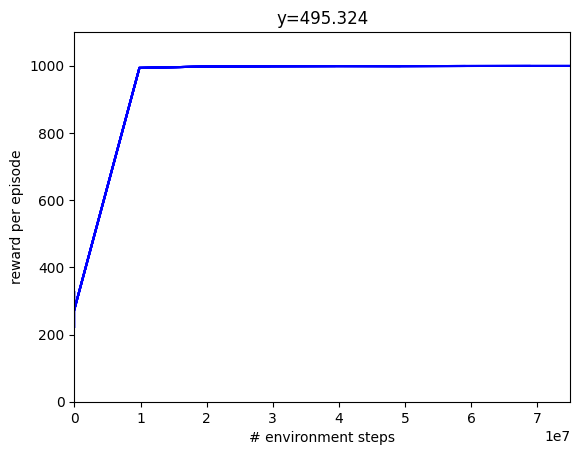

In [8]:
from mujoco_playground.config import dm_control_suite_params
ppo_params = dm_control_suite_params.brax_ppo_config('CartpoleBalance')
print(ppo_params)


x_data, y_data, y_dataerr = [], [], []
times = [datetime.now()]

def progress(num_steps, metrics):
  clear_output(wait = True)
  times.append(datetime.now())
  x_data.append(num_steps)
  y_data.append(metrics["eval/episode_reward"])
  y_dataerr.append(metrics["eval/episode_reward_std"])

  plt.xlim([0, ppo_params["num_timesteps"] * 1.25])
  plt.ylim([0, 1100])
  plt.xlabel("# environment steps")
  plt.ylabel("reward per episode")
  plt.title(f"y={y_data[-1]:.3f}")
  plt.errorbar(x_data, y_data, yerr=y_dataerr, color="blue")

  display(plt.gcf())

ppo_training_params = dict(ppo_params)
network_factory = ppo_networks.make_ppo_networks
if "network_factory" in ppo_params:
  del ppo_training_params["network_factory"]
  network_factory = functools.partial(
      ppo_networks.make_ppo_networks,
      **ppo_params.network_factory
  )

train_fn = functools.partial(
    ppo.train, **dict(ppo_training_params),
    network_factory=network_factory,
    progress_fn=progress
)

from mujoco_playground import wrapper

make_inference_fn, params, metrics = train_fn(
    environment=env,
    wrap_env_fn=wrapper.wrap_for_brax_training,
)

In [9]:
print(ppo_params)

action_repeat: 1
batch_size: 1024
discounting: 0.995
entropy_cost: 0.01
episode_length: 1000
learning_rate: 0.001
normalize_observations: true
num_envs: 2048
num_evals: 10
num_minibatches: 32
num_resets_per_eval: 10
num_timesteps: 60000000
num_updates_per_batch: 16
reward_scaling: 10.0
unroll_length: 30



In [11]:
jit_reset = jax.jit(env.reset)
jit_step = jax.jit(env.step)
jit_inference_fn = jax.jit(make_inference_fn(params, deterministic=True))
rng = jax.random.PRNGKey(42)
rollout = []
n_episodes = 1

for _ in range(n_episodes):
  state = jit_reset(rng)
  rollout.append(state)
  for i in range(config.episode_length):
    act_rng, rng = jax.random.split(rng)
    ctrl, _ = jit_inference_fn(state.obs, act_rng)
    state = jit_step(state, ctrl)
    rollout.append(state)
i
render_every = 1
frames = env.render(rollout[::render_every])
rewards = [s.reward for s in rollout]
media.show_video(frames, fps=1.0 / env.dt / render_every)

100%|██████████| 1001/1001 [00:51<00:00, 19.39it/s]


This browser does not support the video tag.


In [12]:
print("timesteps:", x_data)
print("rewards:", y_data)
print("std:", y_dataerr)

timesteps: [0, 9830400, 19660800, 29491200, 39321600, 49152000, 58982400, 68812800, 78643200, 88473600]
rewards: [np.float32(275.1083), np.float32(993.5241), np.float32(997.53394), np.float32(998.2457), np.float32(998.74695), np.float32(998.52203), np.float32(999.2214), np.float32(999.547), np.float32(999.5648), np.float32(495.32397)]
std: [np.float32(54.875637), np.float32(0.4851307), np.float32(2.1102743), np.float32(1.4689312), np.float32(1.0064783), np.float32(1.2408204), np.float32(0.6432276), np.float32(0.3779413), np.float32(0.40719774), np.float32(81.44881)]


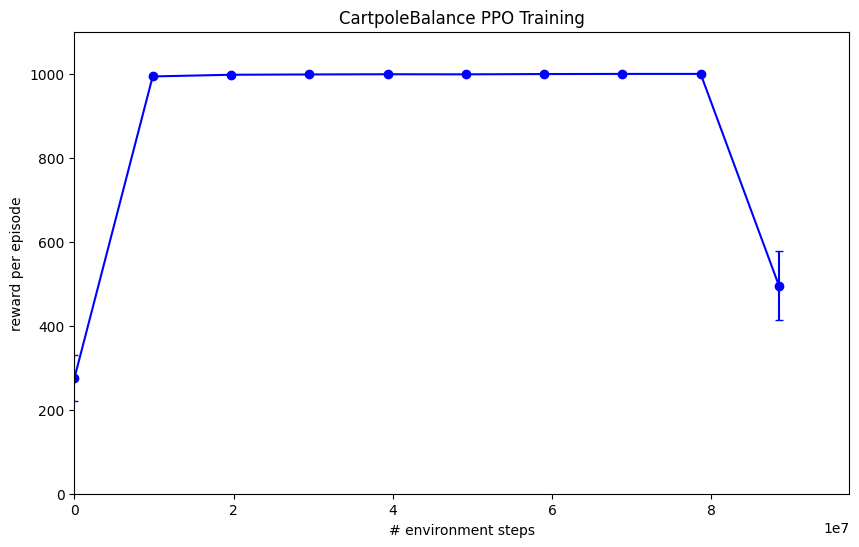

In [13]:
plt.figure(figsize=(10, 6))

plt.xlim([0, max(x_data) * 1.1])
plt.ylim([0, 1100])

plt.xlabel("# environment steps")
plt.ylabel("reward per episode")
plt.title("CartpoleBalance PPO Training")

plt.errorbar(
    x_data,
    y_data,
    yerr=y_dataerr,
    color="blue",
    marker="o",
    capsize=3
)

plt.show()